# Paris Residential AVM — walkthrough

Estimating the asking price of a Paris flat from its listing attributes:
surface, location, layout, amenities and energy rating.

This notebook is the short version. It calls the `paris_avm` package rather
than repeating the code inline, so the narrative stays readable and the logic
stays testable. The longer, exploratory original is in
`00_original_exploration.ipynb`.

**About the data.** The project was built on a private extract of 100,000
Paris listings that cannot be redistributed. Everything below runs on a
synthetic extract with the same schema and the same defects, generated by
`scripts/make_synthetic_data.py`. The numbers here are therefore *not* the
numbers from the original run — those are quoted in the README.

In [ ]:
%matplotlib inline

from pathlib import Path

import numpy as np
import pandas as pd

from paris_avm import cleaning, config, data, evaluation, features, modeling, plots

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

## 1. Load and audit

Before changing anything, look at what is wrong. Four questions: what is
missing, what is duplicated, what is geographically impossible, and what is
numerically impossible.

In [2]:
DATA = Path.cwd().parent / "data" / "listings_synthetic.csv"
df_raw = data.load_raw(DATA)
print(f"{df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
df_raw.head(3)

30,000 rows x 35 columns


,Unnamed: 0,external_id,client_id,address_id,street_id,iris_id,parcel_id,city,city_id,zipcode,price,area,floor,floor_count,room_count,bedroom_count,bathroom_count,toilet_count,balcony_count,terrace_count,balcony_area,terrace_area,parking_boxe_count,parking_inside_count,parking_garage_count,site_area,has_cellar,has_passenger_lift,build_year,item_type,item_subtype,energy_certificate_efficiency_score,start_date,end_date,publish_start_date
0,8225,39925949,3117,582823.0,36975.0,751743,NaN,Paris,75056,75006,1410000.0,69.0,4.0,NaN,3.0,2.0,NaN,1.0,0,0,NaN,NaN,0.0,NaN,NaN,NaN,1.0,NaN,NaN,ITEM_TYPE.APARTMENT,ITEM_TYPE.APARTMENT.STUDIO,NaN,2025-03-14,2025-10-20,2025-03-15
1,10794,68584580,2381,800983.0,63277.0,751449,NaN,Paris,75056,75006,1086000.0,61.0,1.0,3.0,2.0,1.0,1.0,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,ITEM_TYPE.APARTMENT,ITEM_TYPE.APARTMENT.FLAT,NaN,2025-02-27,2025-05-12,2025-02-28
2,9163,29146151,4126,145107.0,20156.0,751429,NaN,Paris,75056,75014,2000000.0,178.0,NaN,6.0,7.0,5.0,NaN,3.0,0,0,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,1972.0,ITEM_TYPE.APARTMENT,ITEM_TYPE.APARTMENT.FLAT,ENERGY.CERTIFICATE_EFFICIENCY_SCORE.D,2025-12-09,2026-01-29,2025-12-11


In [3]:
audit = data.quality_report(df_raw)

print("Top missing columns (%):")
print(audit["missing_pct"].head(8).round(1).to_string())
print(f"\n{len(audit['duplicate_external_ids']):,} external_ids appear more than once")
print(f"{int(audit['invalid_zipcodes'].sum()):,} rows carry a zipcode that is not a Paris arrondissement:")
print(audit["invalid_zipcodes"].to_string())

Top missing columns (%):
parking_garage_count    100.0
site_area               100.0
parcel_id               100.0
terrace_area             71.0
balcony_area             66.0
parking_inside_count     64.0
parking_boxe_count       62.0
build_year               53.0

35 external_ids appear more than once
314 rows carry a zipcode that is not a Paris arrondissement:
zipcode
75116    179
75108     30
75550     30
75107     30
75000     30
75023     15


In [4]:
audit["numeric_ranges"].loc[
    ["price", "area", "room_count", "bedroom_count", "floor", "floor_count", "build_year"]
]

,min,max,n_negative,pct_missing
price,19000.0,9716000.0,0,0.0
area,9.0,3970.0,0,0.0
room_count,-1.0,290.0,59,3.0
bedroom_count,-1.0,9.0,54,8.0
floor,0.0,119.0,0,22.0
floor_count,1.0,22.0,0,31.0
build_year,0.0,3021.0,0,53.0


Negative bedroom counts, a build year of 0, three-hundred-room flats.
None of these are observations — they are entry errors, and they need
different treatment from genuine outliers.

## 2. Clean

The rules live in `config.py` and the steps in `cleaning.py`. The two
decisions worth defending:

**Impossible values become NaN, they do not drop the row.** A listing with
`-1` bedrooms still has a valid price, surface and address. Nulling the one
broken field keeps the other 30 usable.

**Rows outside the market bounds are dropped, not repaired.** A EUR 12,000
"flat" or a EUR 2,000/sqm listing in Paris is not a mispriced apartment; it
is a different object — a parking space, a share of undivided property, a
placeholder. Imputing it would teach the model a price level that does not
exist.

In [5]:
df, log = cleaning.clean(df_raw)

                    step  rows                                                                                              note  retained_pct
                     raw 30000                                                                                                          100.00
       zipcodes repaired 30000                                                                                     45 set to NaN        100.00
         columns dropped 30000                                                                        near-constant: ['city_id']        100.00
     re-listings removed 29965                                                                                          -35 rows         99.88
        residential only 29845                                                                                         -120 rows         99.48
impossible values nulled 29845                                                                                                           99.48

## 3. Feature engineering

Fourteen derived features, in four groups:

| Group | Features | Why |
|---|---|---|
| Time | `listing_month`, `listing_quarter`, `listing_dow`, `property_age` | seasonality and building age |
| Size & layout | `area_per_room`, `area_per_bedroom`, `outdoor_area`, `total_parking` | 90 sqm across two rooms is a different product from 90 sqm across four |
| Building | `floor_ratio` | third of four is a top floor; third of twenty is not |
| Geography | `arrondissement`, `rive_gauche`, `prime_arrondissement` | a zipcode integer has no order the model can use; these do |

`price_per_sqm`, `log_price` and `days_on_market` are built here for the EDA
but deliberately kept out of the feature list — the first two are functions
of the target, the third is only known once the listing has closed.

In [6]:
df, feature_cols = features.engineer(df)
print(f"{len(feature_cols)} features")
print(feature_cols)

32 features
['area', 'room_count', 'bedroom_count', 'bathroom_count', 'toilet_count', 'floor', 'floor_count', 'floor_ratio', 'build_year', 'property_age', 'arrondissement', 'rive_gauche', 'prime_arrondissement', 'has_passenger_lift', 'has_cellar', 'balcony_count', 'terrace_count', 'outdoor_area', 'total_parking', 'energy_score_ordinal', 'area_per_room', 'area_per_bedroom', 'listing_month', 'listing_quarter', 'listing_dow', 'type_HOUSE', 'subtype_APARTMENT.FLAT', 'subtype_APARTMENT.LOFT', 'subtype_APARTMENT.PENTHOUSE', 'subtype_APARTMENT.STUDIO', 'subtype_HOUSE.TOWNHOUSE', 'subtype_HOUSE.VILLA']


## 4. What the data says

Charts are rendered as static PNGs into `reports/figures/` rather than as
interactive widgets, so the committed notebook stays small and readable in
a diff.

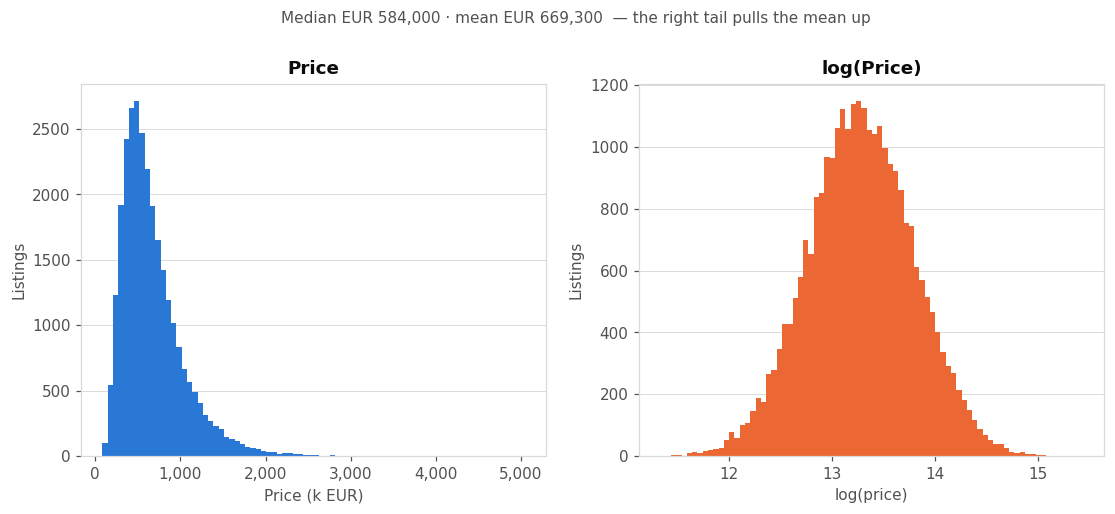

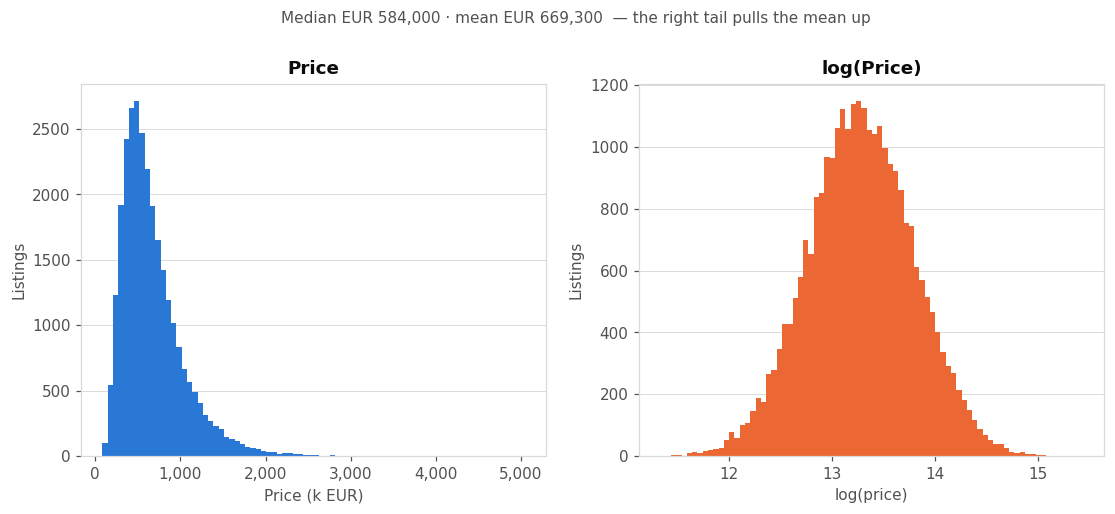

In [7]:
plots.price_distribution(df, outdir=None)

The price distribution is heavily right-skewed: a long tail of expensive
properties pulls the mean well above the median. Taking the log makes it
almost symmetric — the standard fix, and the reason section 6 tests it
rather than assuming it.

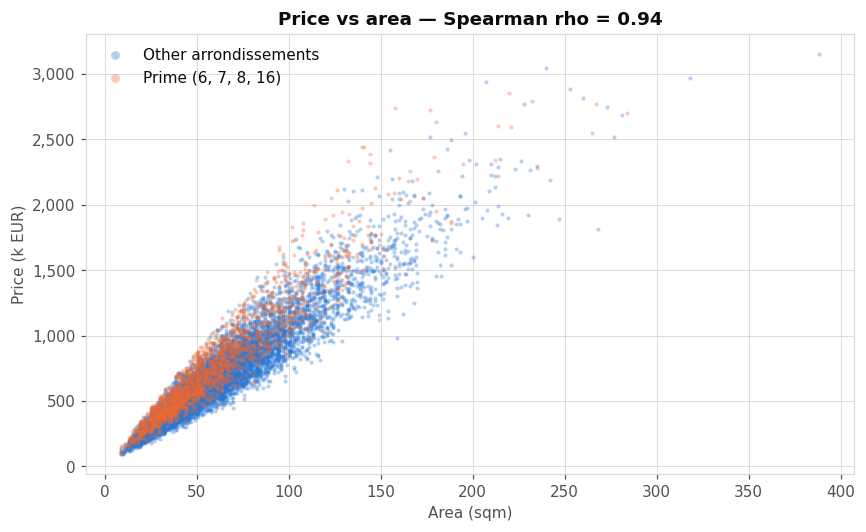

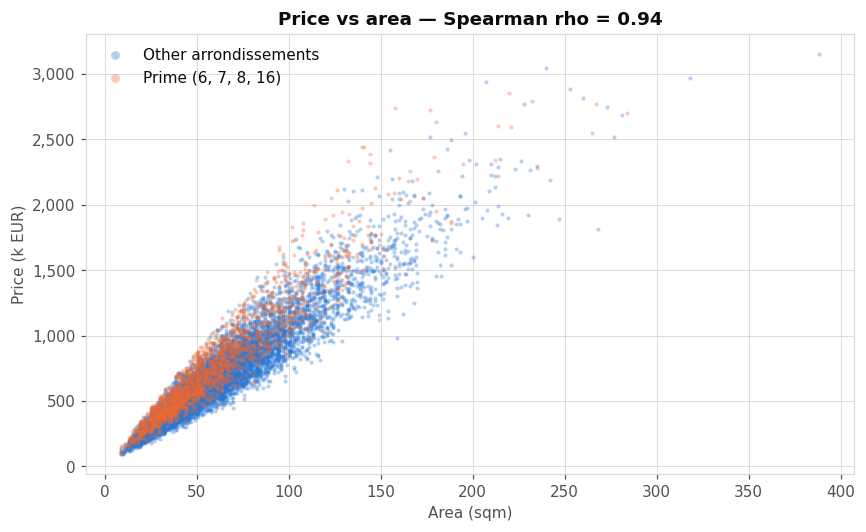

In [8]:
plots.price_vs_area(df, outdir=None)

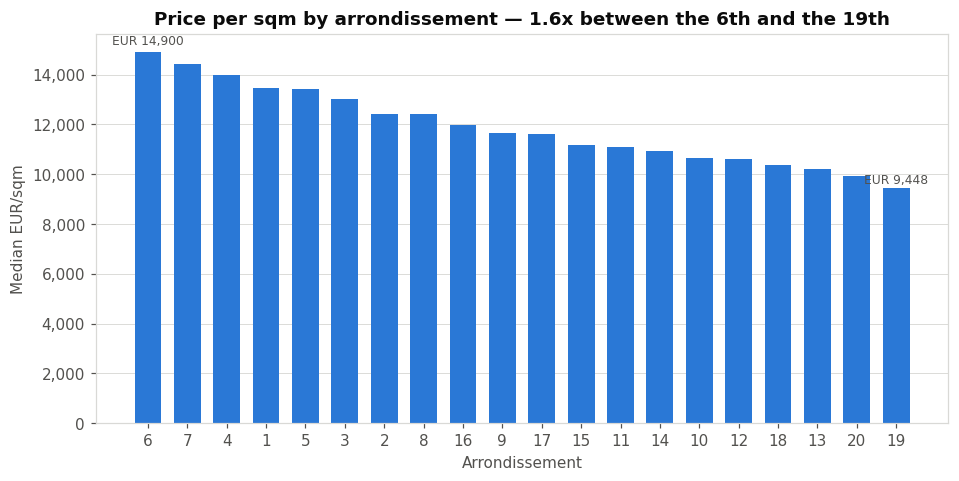

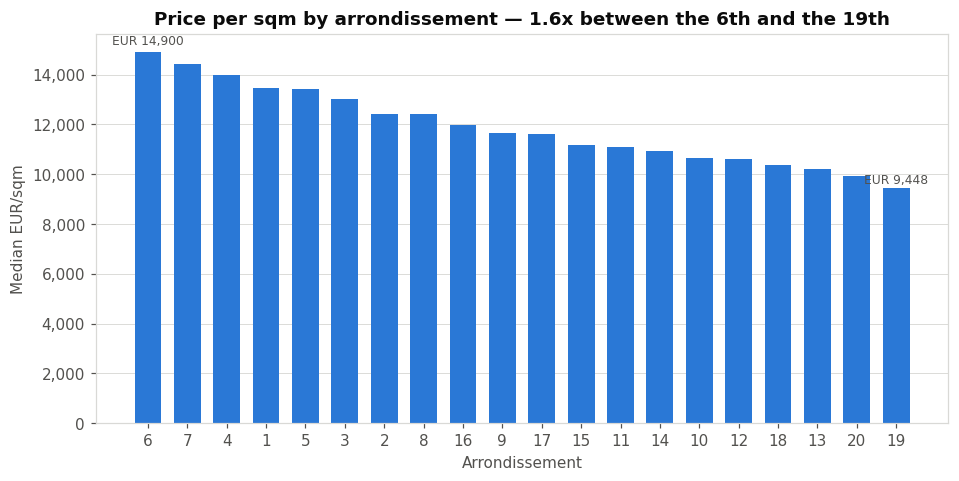

In [9]:
plots.price_per_sqm_by_arrondissement(df, outdir=None)

Surface is the dominant driver, and location moves the price per square
metre by a wide margin across arrondissements. Together they are most of the
model.

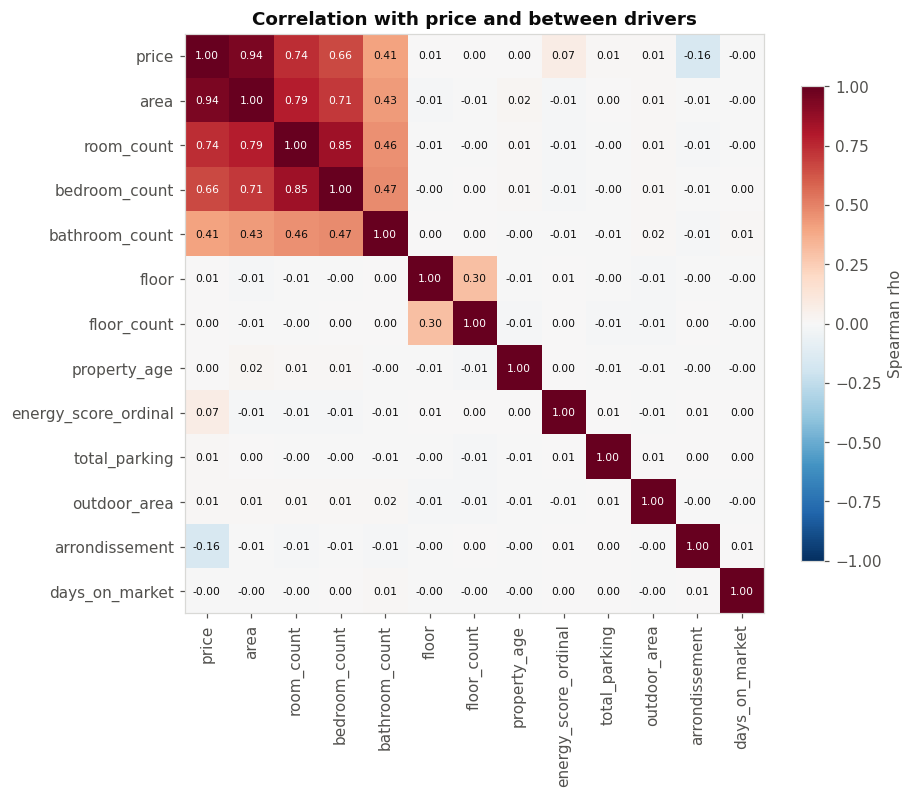

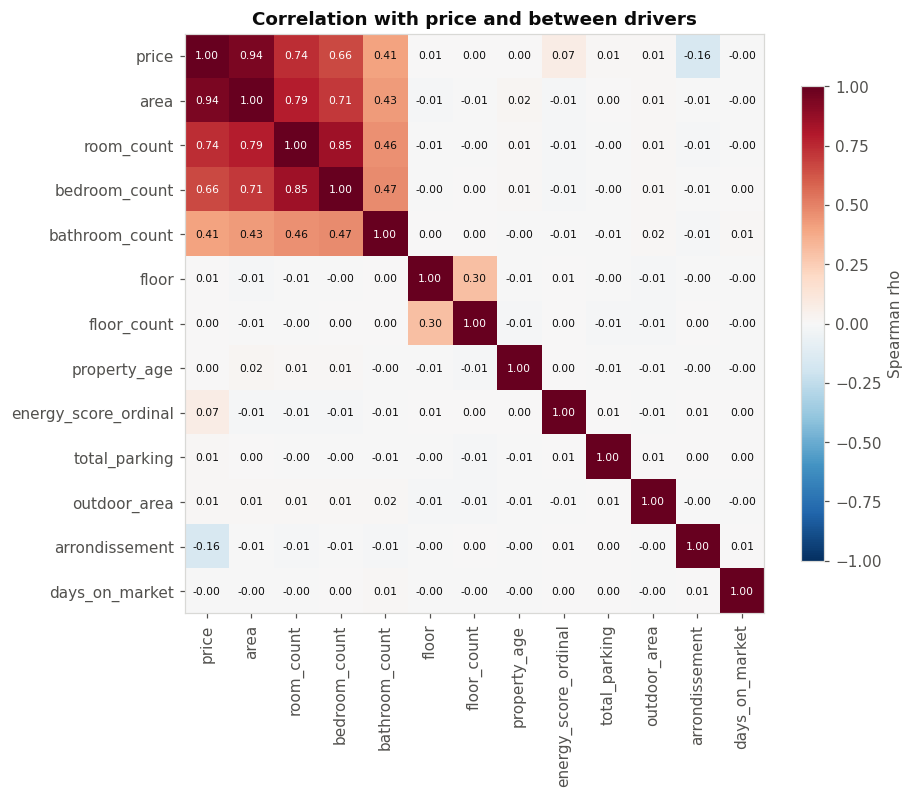

In [10]:
plots.correlation_heatmap(df, outdir=None)

## 5. Split, impute, scale

Imputer and scaler are fitted on the training set only. Fitting them on the
full frame first would leak the test set's medians and variance into the
transformation and flatter every score that follows.

In [11]:
split = modeling.make_split(df, feature_cols)
print(f"train {split.X_train.shape[0]:,} rows | test {split.X_test.shape[0]:,} rows")

train 22,700 rows | test 5,675 rows


## 6. Raw price or log price?

Log-transforming a skewed target is the textbook move. But the deliverable
here is a euro estimate, and the back-transform re-introduces its own bias,
so the question is settled by measurement rather than convention.

In [12]:
modeling.compare_target_transforms(split)

,target,MAE,RMSE,R2
0,raw price,75335.411497,107100.312844,0.916118
1,log price,110874.286404,229737.359055,0.614031


Raw price wins on the metric that matters, so every model below is trained
on the untransformed target.

## 7. Models

Six models on the same split: three linear, three tree ensembles. Linear
models get scaled inputs; trees get imputed inputs only, since a split-based
learner is indifferent to scale.

In [13]:
results = modeling.train_all(split)
board = modeling.leaderboard(results)
board

Linear Regression    | MAE: EUR     75,335 | RMSE: EUR    107,100 | R2: 0.9161
Ridge                | MAE: EUR     75,337 | RMSE: EUR    107,098 | R2: 0.9161


Lasso                | MAE: EUR     75,336 | RMSE: EUR    107,100 | R2: 0.9161


Random Forest        | MAE: EUR     67,544 | RMSE: EUR     98,870 | R2: 0.9285


Gradient Boosting    | MAE: EUR     63,896 | RMSE: EUR     92,905 | R2: 0.9369


XGBoost              | MAE: EUR     64,371 | RMSE: EUR     92,948 | R2: 0.9368


,Model,Test MAE (EUR),Test RMSE (EUR),Test R2
0,Gradient Boosting,63896.458152,92905.009632,0.936880
1,XGBoost,64371.049237,92948.175620,0.936821
2,Random Forest,67544.032086,98869.528876,0.928515
3,Ridge,75336.778959,107097.787072,0.916122
4,Lasso,75336.216180,107100.070273,0.916118
5,Linear Regression,75335.411497,107100.312844,0.916118


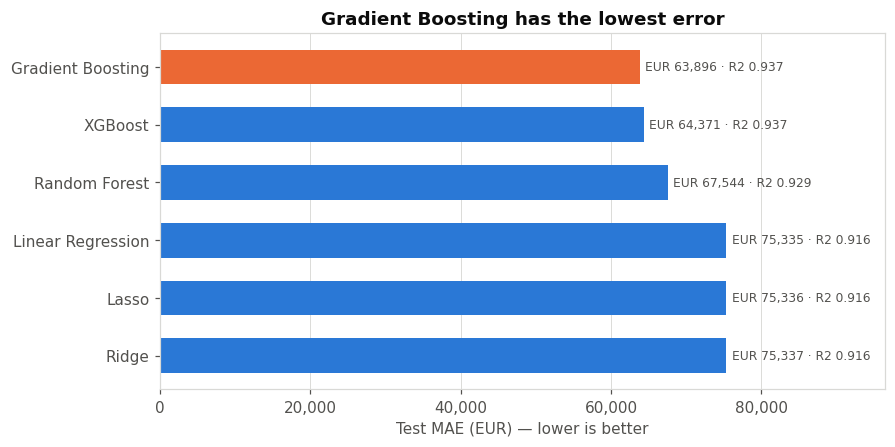

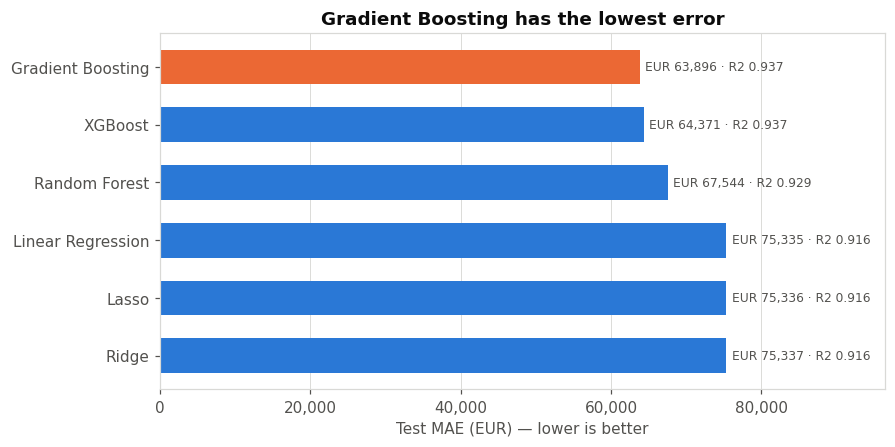

In [14]:
best_name = board.loc[0, "Model"]
best = results[best_name]
plots.model_comparison(board, outdir=None)

The tree ensembles beat the linear models by a wide margin, which is what
the price-versus-area plot predicted: the relationship bends, and a straight
line through it cannot follow the bend. Ridge and Lasso differ from plain
linear regression only in how they penalise coefficients — they are still
drawing a line.

## 8. Diagnostics

A single MAE hides the thing a valuation product needs to know: the error is
not spread evenly.

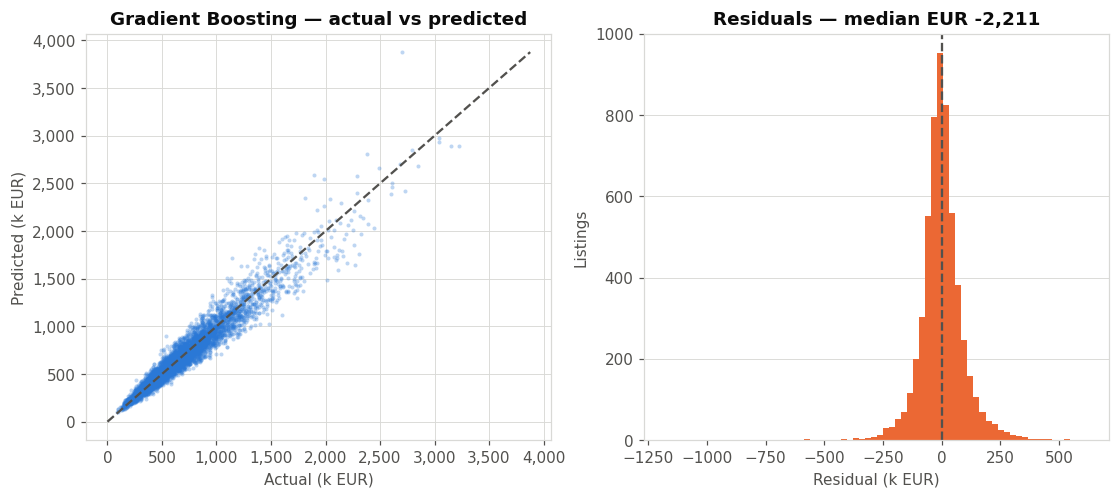

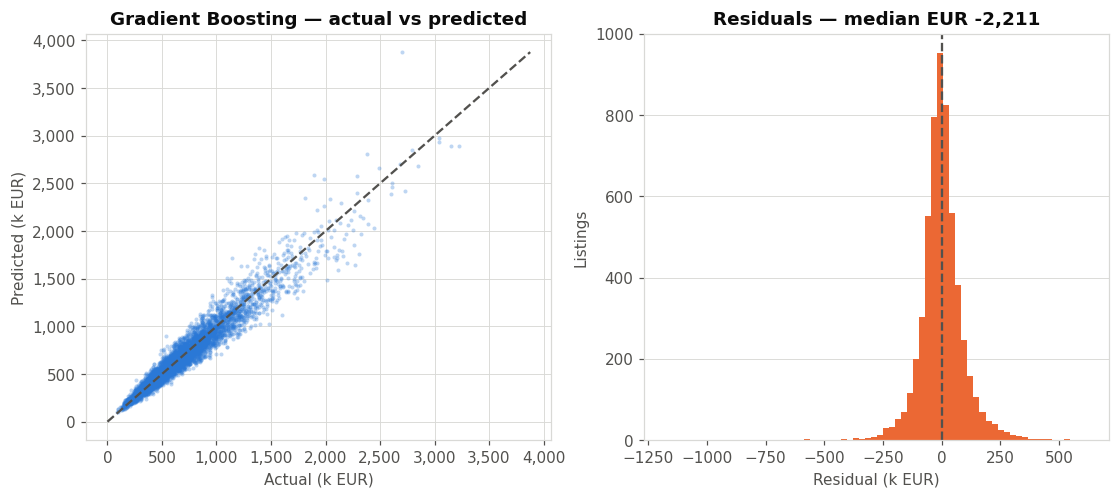

In [15]:
plots.predicted_vs_actual(split.y_test, best["pred"], best_name, outdir=None)

In [16]:
seg = evaluation.error_by_segment(split.y_test, best["pred"])
seg

,n,mean_price,MAE,MAPE
bucket,,,,
Q1 (cheapest),1139,292952.6,30266.5,10.6
Q2,1131,447362.5,40935.3,9.2
Q3,1139,588719.9,55089.8,9.3
Q4,1133,777865.8,71762.1,9.2
Q5 (priciest),1133,1254059.1,121612.7,9.6


Absolute error grows with price while percentage error shrinks: the model is
relatively better on expensive properties and absolutely worse. A product
built on this should widen the displayed interval for the top segment.

,feature,importance,kind
0,area,0.928990,impurity importance
1,arrondissement,0.049992,impurity importance
2,prime_arrondissement,0.007607,impurity importance
3,energy_score_ordinal,0.004361,impurity importance
4,room_count,0.002126,impurity importance
5,area_per_bedroom,0.000883,impurity importance
6,bedroom_count,0.000703,impurity importance
7,area_per_room,0.000588,impurity importance
8,rive_gauche,0.000563,impurity importance
9,has_passenger_lift,0.000523,impurity importance


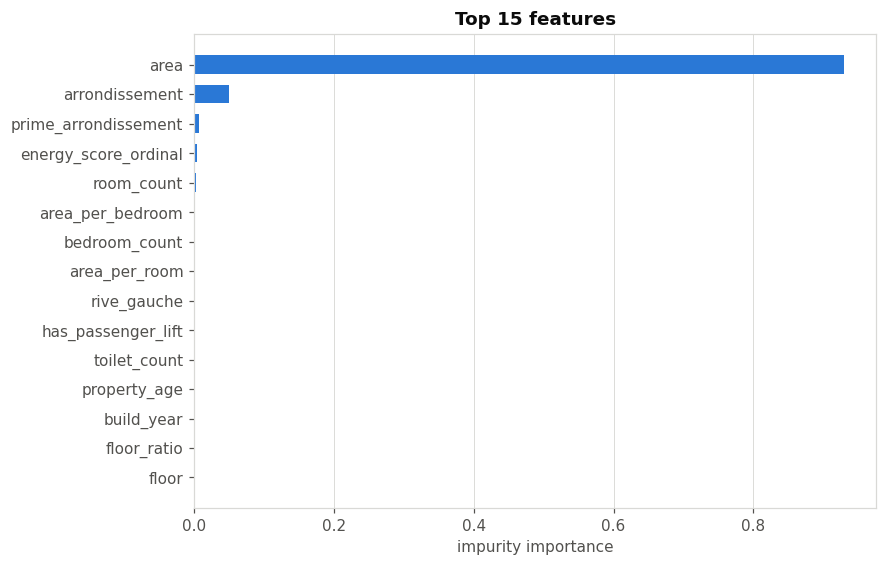

In [17]:
importance = evaluation.feature_importance(best["model"], feature_cols)
plots.feature_importance(importance, outdir=None)
importance.head(10)

In [18]:
lo, hi = evaluation.prediction_interval(split.y_test, best["pred"], coverage=0.8)
print(f"80% of residuals fall in [EUR {lo:,.0f}, EUR {hi:,.0f}]")
print("-> the estimate should be published as an interval, not a point")

80% of residuals fall in [EUR -94,461, EUR 102,433]
-> the estimate should be published as an interval, not a point


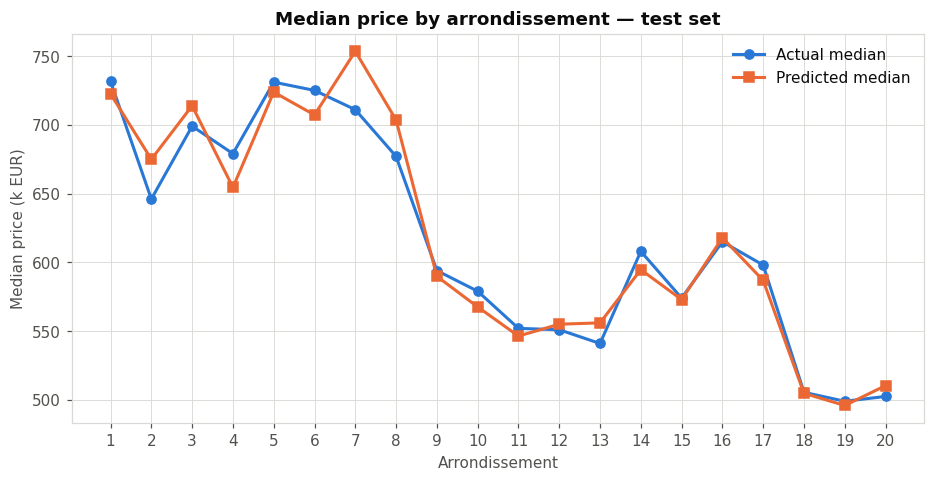

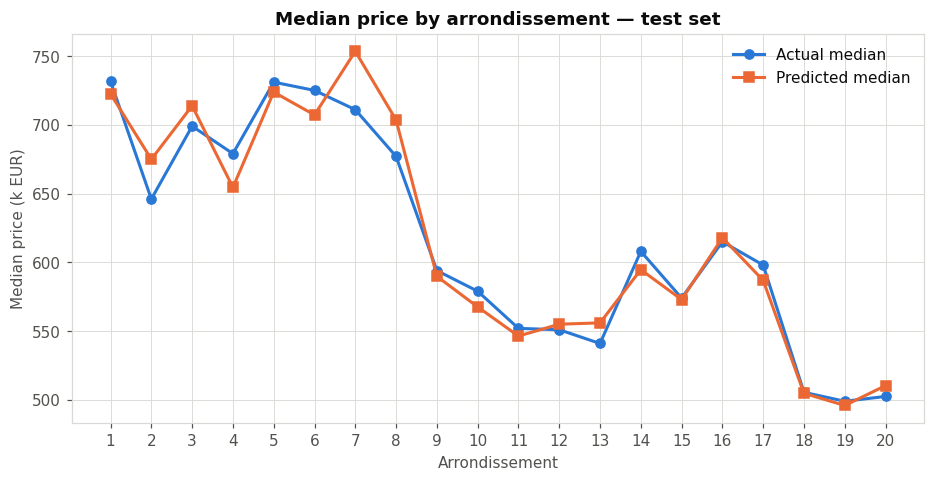

In [19]:
by_arr = evaluation.error_by_group(
    split.y_test, best["pred"], split.X_test["arrondissement"], "arrondissement"
)
plots.actual_vs_predicted_by_arrondissement(by_arr, outdir=None)

The model reproduces the price ranking across arrondissements, so it has
learned the geography rather than an average Paris price.

## 9. What this would need before it shipped

- **Publish an interval, not a number.** A single figure implies a precision
  the model does not have. The residual quantiles above give the width.
- **Flag low-confidence estimates.** A listing missing surface, floor and
  energy rating should visibly carry a weaker estimate than a complete one.
- **Expect worse accuracy on unusual properties.** Rare or exceptional
  listings have few comparables to learn from.
- **Missing drivers.** Transport, schools and street-level quality are all
  known price drivers and none of them are in this dataset.
- **One year of data.** Seasonality cannot be separated from trend on a
  single year, and the level will not hold beyond it. Retraining cadence and
  drift monitoring are part of the deployment, not an afterthought.